In [1]:
from PyClasses.FEAssembly import *
from PyClasses.Contacts import *
from PyClasses.FEModel import *
import sys, os, pickle
import numpy as np
from time import time
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
# os.chdir(sys.path[0])

# POTATO
[ptt] = pickle.load(open("PointsCreation/PotatoAssembly.dat","rb"))
ptt.isRigid = True     # faster solving when True
ndofs = 3*len(ptt.X)

# MODEL
model = FEModel([ptt], [],[])           # [bodies, contacts, BCs, opts*]
ptt.Translate([-6.0, 0.0, 0.0])
model.X = ptt.X.ravel()
ptt.surf.ComputeGrgPatches(np.zeros(ndofs),range(len(ptt.surf.nodes)))

In [3]:
model_X = model.X.reshape(-1,3)
xa,xb = min(model_X[:,0]), max(model_X[:,0])
ya,yb = min(model_X[:,1]), max(model_X[:,1])
za,zb = min(model_X[:,2]), max(model_X[:,2])

In [4]:
offset = 0.1
dx, dy, dz = offset*np.array([xb-xa,yb-ya,zb-za])
xmin, xmax = xa-dx, xb+dx
ymin, ymax = ya-dy, yb+dy
zmin, zmax = za-dz, zb+dz

In [5]:
bounding_box = np.array([[xmin, ymin, zmin],
                         [xmin, ymin, zmax],
                         [xmin, ymax, zmin],
                         [xmin, ymax, zmax],
                         [xmax, ymin, zmin],
                         [xmax, ymin, zmax],
                         [xmax, ymax, zmin],
                         [xmax, ymax, zmax]])

In [6]:
# Connect the bounding box points
edges = [
    [0, 1], [0, 2], [0, 4], [1, 3], [1, 5], [2, 3], [2, 6], [3, 7],
    [4, 5], [4, 6], [5, 7], [6, 7]
]

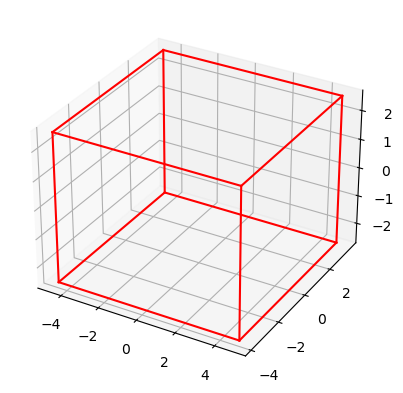

In [7]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
for edge in edges:
    ax.plot3D(*zip(*bounding_box[edge]), color="r")
plt.show()

In [8]:
points_per_side = 2
xs = np.zeros((points_per_side*points_per_side*points_per_side , 3))

# Generate set of points in space
locator_index = 0
for x in np.linspace(xmin,xmax, points_per_side):
    for y in np.linspace(ymin,ymax, points_per_side):
        for z in np.linspace(zmin,zmax, points_per_side):
            xs[locator_index] = np.array([x,y,z])
            locator_index += 1

In [9]:
# Iterate over points generated to get closest patch and surface parameters
patches = model.bodies[0].surf.patches
npatches = len(patches)
raw_distances = np.zeros(npatches)

In [10]:
xm_matrix = np.zeros((npatches,3))
for ip,patch in enumerate(patches):
    xm_matrix[ip] = patch.BS.x
distance_matrix = np.linalg.norm(xm_matrix[:, np.newaxis, :] - xs, axis=2)

In [11]:
candidates = []
for i,xsi in enumerate(xs):
    
    raw_distances = distance_matrix[:,i]
    sorted_indices = np.argsort(raw_distances)
    # candidates.append(sorted_indices[0:45])
    candidates.append(sorted_indices[0:5])
candidates = np.array(candidates)


# TR method to find closest point on surface patch
t1t2_init = [[0,0],[0.5,0],[1,0],[0,0.5],[0.5,0.5],[1,0.5],[0,1.0],[0.5,1.0],[1,1.0]]
eps_min = 1e-15

TR_max = 1.0
TR_min = 1e-12
OUTMAT_final = np.zeros((len(xs),23))

stt = time()
for i,xsi in enumerate(xs):
    # t1t2 = np.zeros((len(candidates[i]),2))
    # gns = np.zeros(len(candidates[i])) 
    OUTMAT=np.zeros((len(candidates[i]),4))
    for ip,patch in enumerate(candidates[i]):
        outmat = np.zeros((9,3))
        for j in range(9):
            t1t2 = t1t2_init[j]
            xc = patches[patch].Grg0(t1t2)
            m_new = np.linalg.norm(xsi - xc)**2
            m_old = 1e10
            flag_new_u = 1.0
            cnt1 = 0
            
            TR_radius = 0.000001#0.01
            while m_new < m_old:
                cnt1 += 1
                #print("cnt1", cnt1)
                # print("t1t2", t1t2)
                if flag_new_u ==1:
                    xc, dxcdt, d2xcd2t = patches[patch].Grg(t1t2, deriv=2)
                    f = 2*(xc - xsi) @ dxcdt
                    # print(xc.shape)
                    # print((xc - xsi) @ d2xcd2t)
                    # print(np.tensordot(xsi-xc,d2xcd2t,axes=1).shape)
                    # print(d2xcd2t.shape)
                    # print(dxcdt.shape)
                    # print((dxcdt @ dxcdt).shape)
                    # print(dxcdt.T @ dxcdt)
                    # print(np.einsum('i,ijk->jk', (xc - xsi), d2xcd2t).shape)
                    K = 2*(dxcdt.T @ dxcdt + np.einsum('i,ijk->jk', (xc - xsi), d2xcd2t))
                r = -f
                p = r
                q= p 
                h = np.zeros(2)
                flag_boundary_reached = 0
                bla = 1.0
                # cnt2 = 0
                while bla > 0:
                    # cnt2 += 1
                    # print("cnt2", cnt2)
                    if np.dot(np.dot(p.T, K),p) <= 0:
                        flag_boundary_reached = 1
                        a = np.dot(p.T, p)
                        b = 2*np.dot(p.T, h)
                        c = np.dot(h.T, h) - TR_radius**2
                        alpha = (-b + np.sqrt(b**2 - 4*a*c)) / (2*a)
                        h = h + alpha*p
                        break
                    alpha = np.dot(r.T, q)/ np.dot(np.dot(p.T, K),p)
                    if np.dot((h + alpha*p).T, (h + alpha*p)) >= TR_radius**2:
                        flag_boundary_reached = 1
                        a = np.dot(p.T, p)
                        b = 2*np.dot(p.T, h)
                        c = np.dot(h.T, h) - TR_radius**2
                        alpha = (-b + np.sqrt(b**2 - 4*a*c)) / (2*a)
                        h = h + alpha*p
                        break
                    h = h + alpha*p
                    phi = np.dot(r.T, p)
                    r = r - alpha * np.dot(K, p)
                    # print(np.max([1.0e-15, 1.0e-5 * np.linalg.norm(f)]))
                    # print("ffffff", np.linalg.norm(f))
                    # print("ffffff", np.linalg.norm(r))
                    # print("ffffff", 1.0e-5 * np.linalg.norm(f))
                    if np.linalg.norm(r) < np.max([1e-15, 1.0e-5 * np.linalg.norm(f)]):
                        break 
                    q = r
                    p = q + (np.dot(r.T, q))/(phi) * p
                m_new_plus_h = np.linalg.norm(xsi - patches[patch].Grg0(t1t2 + h))**2
                ratio  = (m_new - m_new_plus_h) / (-np.dot(f.T, h) - 0.5 *np.dot(np.dot(h.T, K),h))
                if ratio < 0.25:
                    TR_radius = 0.25 * TR_radius
                    flag_new_u = 0.0
                else: 
                    t1t2 += h
                    if ratio > 0.75 and flag_boundary_reached == 1:
                        TR_radius = min(2.0 * TR_radius, TR_max) 
                    flag_new_u = 1.0
                if (TR_radius < TR_min) | (t1t2[0] < -0.5) | (t1t2[0] > 1.5) | (t1t2[1] < -0.5) | (t1t2[1] > 1.5): #np.linalg.norm(f)< 1e-12: #TR_radius < TR_min:
                    #print("TR radius below minimum","\n", 
                     #     "xsi", xsi, "patch_id", patch, "t1t2_init", t1t2_init[j])
                    break
                if flag_new_u == 1.0:
                    m_old = m_new
                    m_new = m_new_plus_h   

            outmat[j,:] = [m_new, t1t2[0], t1t2[1]]
        #
        # print(((outmat[:,1]>=eps_min) and (outmat[:,1]<=1.0)) and ((outmat[:,2]>=eps_min) and (outmat[:,2]<=1.0)))
        # outmat_filtered = outmat[((outmat[:,1]>=eps_min) and (outmat[:,1]<=1.0)) and ((outmat[:,2]>=eps_min) and (outmat[:,2]<=1.0))]
        outmat_filtered = outmat[ ((outmat[:, 1] >= eps_min) & (outmat[:, 1] <= 1.0)) &     ((outmat[:, 2] >= eps_min) & (outmat[:, 2] <= 1.0))]
        # print("outmat_filtered", outmat_filtered)
        if len(outmat_filtered) ==0:
            OUTMAT[ip,:] = [1e10, -1.0, -1.0, candidates[i][ip]]
        else:    
            sorted_outmat = outmat_filtered[np.argsort(outmat_filtered[:,0])]
            # OUTMAT[ip,:] = [sorted_outmat[0,:],candidates[ip]]
            OUTMAT[ip,:] = [sorted_outmat[0,0], sorted_outmat[0,1], sorted_outmat[0,2], candidates[i][ip]]
            
    idx_min = np.argmin(OUTMAT[:,0])
    p_id = int(OUTMAT[idx_min,3])
    print("Closest patch id:", p_id)
    t1t2_min = OUTMAT[idx_min,1:3]
    xc_min, dxcdt, d2xcd2t = patches[p_id].Grg(t1t2_min, deriv=2)
    D1p, D2p = dxcdt.T
    D3p = np.cross(D1p,D2p)
    nor = D3p/np.linalg.norm(D3p)
    normal_min = patches[p_id].D3Grg(t1t2_min)/np.linalg.norm(patches[p_id].D3Grg(t1t2_min))
    #
    gns_min = (xsi - xc_min) @ nor
    gns_min_check = (xsi - xc_min) @ normal_min
    #
    dfdt =  -2*np.tensordot(xsi-xc_min,d2xcd2t,axes=1) + 2*(dxcdt.T @ dxcdt)
    dfdxs = -2*dxcdt.T
    dtdxs = np.linalg.solve(-dfdt,dfdxs)

    # Vars for K---------------------------------------------------
    dndt = patches[p_id].dndt(t1t2_min)
    dndxs = dndt@dtdxs
    OUTMAT_final[i,:] = [int(p_id), t1t2_min[0], t1t2_min[1], xc_min[0], xc_min[1], xc_min[2], gns_min, gns_min_check, normal_min[0], normal_min[1], normal_min[2], \
                         nor[0], nor[1], nor[2], \
                         dndxs[0,0], dndxs[0,1], dndxs[0,2], dndxs[1,0], dndxs[1,1], dndxs[1,2], dndxs[2,0], dndxs[2,1], dndxs[2,2] ]
print("Total time for point projection:", time() - stt)


Closest patch id: 63
Closest patch id: 67
Closest patch id: 14
Closest patch id: 68
Closest patch id: 19
Closest patch id: 27
Closest patch id: 16
Closest patch id: 28
Total time for point projection: 2.481396436691284


In [12]:
xs

array([[-4.57466671, -3.84541787, -2.60818852],
       [-4.57466671, -3.84541787,  2.5896163 ],
       [-4.57466671,  3.60446973, -2.60818852],
       [-4.57466671,  3.60446973,  2.5896163 ],
       [ 4.84927765, -3.84541787, -2.60818852],
       [ 4.84927765, -3.84541787,  2.5896163 ],
       [ 4.84927765,  3.60446973, -2.60818852],
       [ 4.84927765,  3.60446973,  2.5896163 ]])

In [13]:
# Closest patch id: 63
# Closest patch id: 67
# Closest patch id: 14
# Closest patch id: 68
# Closest patch id: 19
# Closest patch id: 27
# Closest patch id: 16
# Closest patch id: 28
# Total time for point projection: 8.715853691101074

In [14]:
# Closest patch id: 63
# Closest patch id: 67
# Closest patch id: 14
# Closest patch id: 68
# Closest patch id: 19
# Closest patch id: 27
# Closest patch id: 16
# Closest patch id: 28
# Total time for point projection: 11.004997491836548

In [15]:
OUTMAT_final.shape

(8, 23)

In [16]:
len(xs)

8

In [17]:
out_f = []
t0 = time()
rec_lvl = 5
for i,xsi in enumerate(xs):
    # for ip,patch in enumerate(patches):
    #     raw_distances[ip] = distance_matrix[ip,i]
    raw_distances = distance_matrix[:,i]


    rec_lvl = 5 # seeding for recursive MinDist search (u_i = np.linspace(x0,x1,seeding+1))
    # get candidates of closest patch
    mindist = min(raw_distances)
    maxdist = max(raw_distances)
    # patch_size = 2.0        # approximate average patch size (observed from BS radius ~1)
    # size_factor = 0.03      # offset percentage for search radius where search_radius = mindist + size_factor*(maxdist-mindist)
    patch_size = 2.5        # approximate average patch size (observed from BS radius ~1)
    size_factor = 0.15      # offset percentage for search radius where search_radius = mindist + size_factor*(maxdist-mindist)
    candidates = [patch for patch, dist in zip(patches, raw_distances) if dist < mindist+size_factor*(maxdist-mindist)]


    print("pt_nr:",i,"\txsi=",xsi, "\ttotal_time:",time()-t0)  # to visualize evolution of computation

    t1t2 = np.zeros((len(candidates),2))
    gns = np.zeros(len(candidates))         # global normal vectors
    nors = np.zeros((len(candidates),3))
    for ip,patch in enumerate(candidates):
        t1t2[ip] = patch.findProjection(xsi,recursive=rec_lvl)
        xc = patch.Grg0(t1t2[ip])
        nor = patch.D3Grg(t1t2[ip])
        gns[ip] = (xsi-xc)@nor
        nors[ip] = nor

    cand_idx =  np.argmin(abs(gns))                   # index of the candidate with smallest angle between x
    patch = candidates[cand_idx]
    pid = patch.iquad                  # index of closest patch
    t1,t2 = t1t2[cand_idx]

    # Unprojected Case!
    trials = 0
    while not((0<=t1<=1) and (0<=t2<=1)):               # loop until a valid projection is found
        trials += 1
        size_factor *= 1.2      # offset percentage for search radius where search_radius = mindist + size_factor*(maxdist-mindist)
        candidates = [patch for patch, dist in zip(patches, raw_distances) if dist < mindist+size_factor*(maxdist-mindist)]
        t1t2 = np.zeros((len(candidates),2))
        gns = np.zeros(len(candidates))         # global normal vectors
        nors = np.zeros((len(candidates),3))
        rec_lvl += 1
        for ip,patch in enumerate(candidates):
            t1t2[ip] = patch.findProjection(xsi,recursive=rec_lvl)
            xc = patch.Grg0(t1t2[ip])
            nor = patch.D3Grg(t1t2[ip])
            inside = ((0<=t1t2[ip][0]<=1) and (0<=t1t2[ip][1]<=1))
            gns[ip] = (xsi-xc)@nor if inside else 1000
            nors[ip] = nor

        cand_idx =  np.argmin(abs(gns))                   # index of the candidate with smallest angle between x
        patch = candidates[cand_idx]
        pid = patch.iquad                  # index of closest patch
        t1,t2 = t1t2[cand_idx]

        if trials>10:
            print("more than 10 trials while looking for projections for point",xsi,".")
            print("last candidates: \n",[cand.iquad for cand in candidates])
            print("p_id:",pid,"\tgn:",gns[cand_idx])
            pass

    out_f.append([xsi[0],xsi[1],xsi[2],pid,t1,t2,gns[cand_idx],nors[cand_idx][0],nors[cand_idx][1],nors[cand_idx][2]])

pt_nr: 0 	xsi= [-4.57466671 -3.84541787 -2.60818852] 	total_time: 0.0003857612609863281
pt_nr: 1 	xsi= [-4.57466671 -3.84541787  2.5896163 ] 	total_time: 0.004162788391113281
pt_nr: 2 	xsi= [-4.57466671  3.60446973 -2.60818852] 	total_time: 0.006650209426879883
pt_nr: 3 	xsi= [-4.57466671  3.60446973  2.5896163 ] 	total_time: 0.009579181671142578
pt_nr: 4 	xsi= [ 4.84927765 -3.84541787 -2.60818852] 	total_time: 0.012945413589477539
pt_nr: 5 	xsi= [ 4.84927765 -3.84541787  2.5896163 ] 	total_time: 0.015304803848266602
pt_nr: 6 	xsi= [ 4.84927765  3.60446973 -2.60818852] 	total_time: 0.01737070083618164
pt_nr: 7 	xsi= [4.84927765 3.60446973 2.5896163 ] 	total_time: 0.019340991973876953


In [18]:
out_f = np.array(out_f)

In [19]:
out_f[:,6]

array([3.06882179, 3.32132093, 2.93115203, 2.87354849, 3.3868077 ,
       3.38591884, 2.96722569, 3.34715452])

In [20]:
out_f[:,6] - OUTMAT_final[:,6]

array([ 8.88178420e-16,  8.88178420e-16,  8.88178420e-16,  2.22044605e-15,
        8.88178420e-16, -8.88178420e-16,  4.44089210e-16,  1.33226763e-15])

In [21]:
OUTMAT_final[:,[6,7]]

array([[3.06882179, 3.06882179],
       [3.32132093, 3.32132093],
       [2.93115203, 2.93115203],
       [2.87354849, 2.87354849],
       [3.3868077 , 3.3868077 ],
       [3.38591884, 3.38591884],
       [2.96722569, 2.96722569],
       [3.34715452, 3.34715452]])

In [22]:
OUTMAT_final[:,6] -OUTMAT_final[:,7]

array([0., 0., 0., 0., 0., 0., 0., 0.])

In [23]:
OUTMAT_final[:,[8,9,10]] - OUTMAT_final[:,[11,12,13]]

array([[ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [-1.11022302e-16,  0.00000000e+00, -1.11022302e-16],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00]])

In [24]:
out_f[:,[7,8,9]] - OUTMAT_final[:,[8,9,10]]

array([[-3.44169138e-15,  4.21884749e-15, -7.21644966e-16],
       [ 1.66533454e-16, -4.44089210e-16, -3.88578059e-16],
       [-1.16817667e-11,  1.23751787e-10,  1.25463750e-10],
       [-5.55111512e-16, -1.11022302e-16, -3.33066907e-16],
       [ 1.08851927e-09,  3.47400020e-09, -2.21506780e-09],
       [ 5.75611891e-10, -3.53865159e-10, -9.37148914e-10],
       [-1.11022302e-16,  1.66533454e-16,  1.11022302e-16],
       [-3.19106230e-09, -8.95879815e-10,  4.72688444e-09]])

In [25]:
OUTMAT_final[0]

array([63.        ,  0.94147734,  0.86763575, -2.58095494, -2.02064908,
       -1.15457253,  3.06882179,  3.06882179, -0.64966684, -0.59461543,
       -0.47367234, -0.64966684, -0.59461543, -0.47367234,  0.16853475,
       -0.11555756, -0.08609144, -0.11555756,  0.19928459, -0.09167471,
       -0.08609144, -0.09167471,  0.23316108])

NotImplementedError: Axes3D currently only supports the aspect argument 'auto'. You passed in 'equal'.

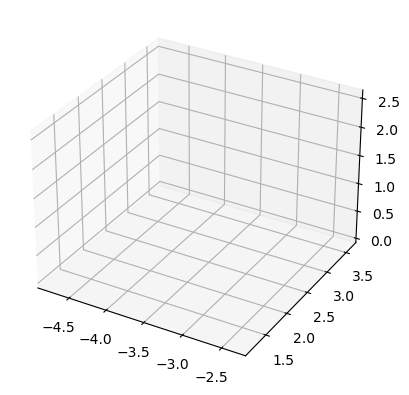

In [27]:
patches[68].plotIsolate(xs[3])

In [ ]:
# # ax = algun axis
# xob= xs[3]
# first_patch = True

# for patchy in patches:
#     # print(patchy)
#     if first_patch:
#         patchy.plotIsolate(xs=xob)#, ax=ax)
#         first_patch=False
#     else:
#         patchy.plotIsolate(xs=None)#, ax=ax)

In [5]:
df = pd.read_feather('Points4Train_LV.ft')

In [6]:
df.head()

,x,y,z,gn,dgn1,dgn2,dgn3,d2gn11,d2gn22,d2gn33,d2gn12,d2gn13,d2gn23
0,-4.574667,-3.845418,-2.608189,3.068822,-0.649667,-0.594615,-0.473672,0.168535,0.199285,0.233161,-0.115558,-0.086091,-0.091675
1,-4.574667,-3.845418,-2.582069,3.056529,-0.651908,-0.597004,-0.467549,0.168458,0.199137,0.235704,-0.116962,-0.085535,-0.091192
2,-4.574667,-3.845418,-2.555949,3.044398,-0.654135,-0.599379,-0.461359,0.168373,0.198981,0.238239,-0.118371,-0.084944,-0.090676
3,-4.574667,-3.845418,-2.529830,3.032429,-0.656345,-0.601740,-0.455104,0.168281,0.198816,0.240766,-0.119782,-0.084316,-0.090127
4,-4.574667,-3.845418,-2.503710,3.020624,-0.658539,-0.604087,-0.448782,0.168182,0.198642,0.243282,-0.121195,-0.083653,-0.089543


In [7]:
df2 = pd.read_feather('Points4Train_TR.ft')

In [8]:
df2.head()

,x,y,z,gn,dgn1,dgn2,dgn3,d2gn11,d2gn22,d2gn33,...,nz_alt_tr,dndxs_11_tr,dndxs_12_tr,dndxs_13_tr,dndxs_21_tr,dndxs_22_tr,dndxs_23_tr,dndxs_31_tr,dndxs_32_tr,dndxs_33_tr
0,-4.574667,-3.845418,-2.608189,3.068822,-0.649667,-0.594615,-0.473672,0.168535,0.199285,0.233161,...,-0.001909,0.100062,-0.129349,-0.097331,-0.129662,0.167614,0.125654,0.003018,-0.004371,0.147183
1,-4.574667,-3.845418,-2.582069,3.056529,-0.651908,-0.597004,-0.467549,0.168458,0.199137,0.235704,...,-0.001909,0.100327,-0.129696,-0.096114,-0.130006,0.168065,0.124077,0.003173,-0.004572,0.147604
2,-4.574667,-3.845418,-2.555949,3.044398,-0.654135,-0.599379,-0.461359,0.168373,0.198981,0.238239,...,-0.001909,0.100596,-0.130049,-0.094884,-0.130356,0.168523,0.122481,0.003329,-0.004776,0.148033
3,-4.574667,-3.845418,-2.529830,3.032429,-0.656345,-0.601740,-0.455104,0.168281,0.198816,0.240766,...,-0.001909,0.100870,-0.130407,-0.093639,-0.130711,0.168988,0.120867,0.003487,-0.004982,0.148468
4,-4.574667,-3.845418,-2.503710,3.020624,-0.658539,-0.604087,-0.448782,0.168182,0.198642,0.243282,...,-0.001909,0.101148,-0.130772,-0.092380,-0.131072,0.169461,0.119234,0.003647,-0.005191,0.148910
